<a href="https://colab.research.google.com/github/Deepank-23/spaceship/blob/main/spaceship_80_08_xg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
!{sys.executable} -m pip install kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c spaceship-titanic

100% 299k/299k [00:00<00:00, 71.4MB/s]



In [ ]:
!unzip -o /content/spaceship-titanic.zip

Archive:  /content/spaceship-titanic.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('train.csv')
df.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [ ]:
df = df.dropna()
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)


Shape: (6606, 14)

Missing values:
 PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

Data types:
 PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object


In [ ]:
df =df.drop('Name',axis=1)

In [ ]:
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
df['CabinNum'] = df['CabinNum'].astype(int)
df['Deck'] = df['Deck'].astype('category').cat.codes
df['Side'] = df['Side'].map({'P':0, 'S':1})

In [ ]:
encoder = LabelEncoder()
df = pd.get_dummies(df, columns=['HomePlanet'], drop_first=True)
df['CryoSleep'] = encoder.fit_transform(df['CryoSleep'])
df = pd.get_dummies(df, columns=['Destination'], drop_first=True)
df['VIP'] = encoder.fit_transform(df['VIP'])

df['Transported'] = encoder.fit_transform(df['Transported'])
print(df)

     PassengerId  CryoSleep     Cabin   Age  VIP  RoomService  FoodCourt  \
0        0001_01          0     B/0/P  39.0    0          0.0        0.0   
1        0002_01          0     F/0/S  24.0    0        109.0        9.0   
2        0003_01          0     A/0/S  58.0    1         43.0     3576.0   
3        0003_02          0     A/0/S  33.0    0          0.0     1283.0   
4        0004_01          0     F/1/S  16.0    0        303.0       70.0   
...          ...        ...       ...   ...  ...          ...        ...   
8688     9276_01          0    A/98/P  41.0    1          0.0     6819.0   
8689     9278_01          1  G/1499/S  18.0    0          0.0        0.0   
8690     9279_01          0  G/1500/S  26.0    0          0.0        0.0   
8691     9280_01          0   E/608/S  32.0    0          0.0     1049.0   
8692     9280_02          0   E/608/S  44.0    0        126.0     4688.0   

      ShoppingMall     Spa  VRDeck  Transported  Deck  CabinNum  Side  \
0             

In [ ]:
df[['group_id', 'member_id']] = (
    df['PassengerId']
    .str.strip()
    .str.split('_', expand=True)
)

df['group_id'] = pd.to_numeric(df['group_id'], errors='coerce')
df['member_id'] = pd.to_numeric(df['member_id'], errors='coerce')

In [ ]:
df.drop(['Cabin','PassengerId'],axis=1,inplace=True)

In [ ]:
# from sklearn.preprocessing import StandardScaler
# df['Age_scaled'] = StandardScaler().fit_transform(df[['Age']])


In [ ]:
# df['Age_bin'] = pd.cut(df['Age'], bins=[0,12,18,30,50,80], labels=['Child','Teen','YoungAdult','Adult','Senior'])
# df = pd.get_dummies(df, columns=['Age_bin'],drop_first=True)

In [ ]:
df['TotalSpending'] = df[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)


In [ ]:
# Loop through all columns and print unique values + counts
for col in df.columns:
    print(f"\nColumn: {col}")
    # print("Unique values:", df[col].unique())
    print("Number of unique values:", df[col].nunique())
    print("Value counts:")
    print(df[col].value_counts().head(10))  # show top 10 for readability



Column: CryoSleep
Number of unique values: 2
Value counts:
CryoSleep
0    4274
1    2332
Name: count, dtype: int64

Column: Age
Number of unique values: 80
Value counts:
Age
24.0    255
18.0    255
22.0    234
21.0    227
19.0    225
23.0    216
26.0    209
28.0    205
20.0    205
25.0    202
Name: count, dtype: int64

Column: VIP
Number of unique values: 2
Value counts:
VIP
0    6444
1     162
Name: count, dtype: int64

Column: RoomService
Number of unique values: 1093
Value counts:
RoomService
0.0     4318
1.0       93
2.0       60
3.0       43
4.0       35
9.0       22
8.0       20
5.0       19
14.0      17
6.0       16
Name: count, dtype: int64

Column: FoodCourt
Number of unique values: 1293
Value counts:
FoodCourt
0.0     4241
1.0       83
2.0       47
4.0       38
3.0       37
5.0       26
10.0      23
9.0       22
7.0       22
6.0       21
Name: count, dtype: int64

Column: ShoppingMall
Number of unique values: 984
Value counts:
ShoppingMall
0.0     4332
1.0      130
2.0      

In [ ]:
 print(df)


      CryoSleep   Age  VIP  RoomService  FoodCourt  ShoppingMall     Spa  \
0             0  39.0    0          0.0        0.0           0.0     0.0   
1             0  24.0    0        109.0        9.0          25.0   549.0   
2             0  58.0    1         43.0     3576.0           0.0  6715.0   
3             0  33.0    0          0.0     1283.0         371.0  3329.0   
4             0  16.0    0        303.0       70.0         151.0   565.0   
...         ...   ...  ...          ...        ...           ...     ...   
8688          0  41.0    1          0.0     6819.0           0.0  1643.0   
8689          1  18.0    0          0.0        0.0           0.0     0.0   
8690          0  26.0    0          0.0        0.0        1872.0     1.0   
8691          0  32.0    0          0.0     1049.0           0.0   353.0   
8692          0  44.0    0        126.0     4688.0           0.0     0.0   

      VRDeck  Transported  Deck  CabinNum  Side  HomePlanet_Europa  \
0        0.0     

In [ ]:
df.dtypes

,0
CryoSleep,int64
Age,float64
VIP,int64
RoomService,float64
FoodCourt,float64
ShoppingMall,float64
Spa,float64
VRDeck,float64
Transported,int64
Deck,int8


In [ ]:
df.head(20)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,group_id,member_id,TotalSpending
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,True,False,False,True,1,1,0.0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,5,0,1,False,False,False,True,2,1,736.0
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,0,0,1,True,False,False,True,3,1,10383.0
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,0,0,1,True,False,False,True,3,2,5176.0
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,5,1,1,False,False,False,True,4,1,1091.0
5,0,44.0,0,0.0,483.0,0.0,291.0,0.0,1,5,0,0,False,False,True,False,5,1,774.0
6,0,26.0,0,42.0,1539.0,3.0,0.0,0.0,1,5,2,1,False,False,False,True,6,1,1584.0
8,0,35.0,0,0.0,785.0,17.0,216.0,0.0,1,5,3,1,False,False,False,True,7,1,1018.0
9,1,14.0,0,0.0,0.0,0.0,0.0,0.0,1,1,1,0,True,False,False,False,8,1,0.0
11,0,45.0,0,39.0,7295.0,589.0,110.0,124.0,1,1,1,0,True,False,False,False,8,3,8157.0


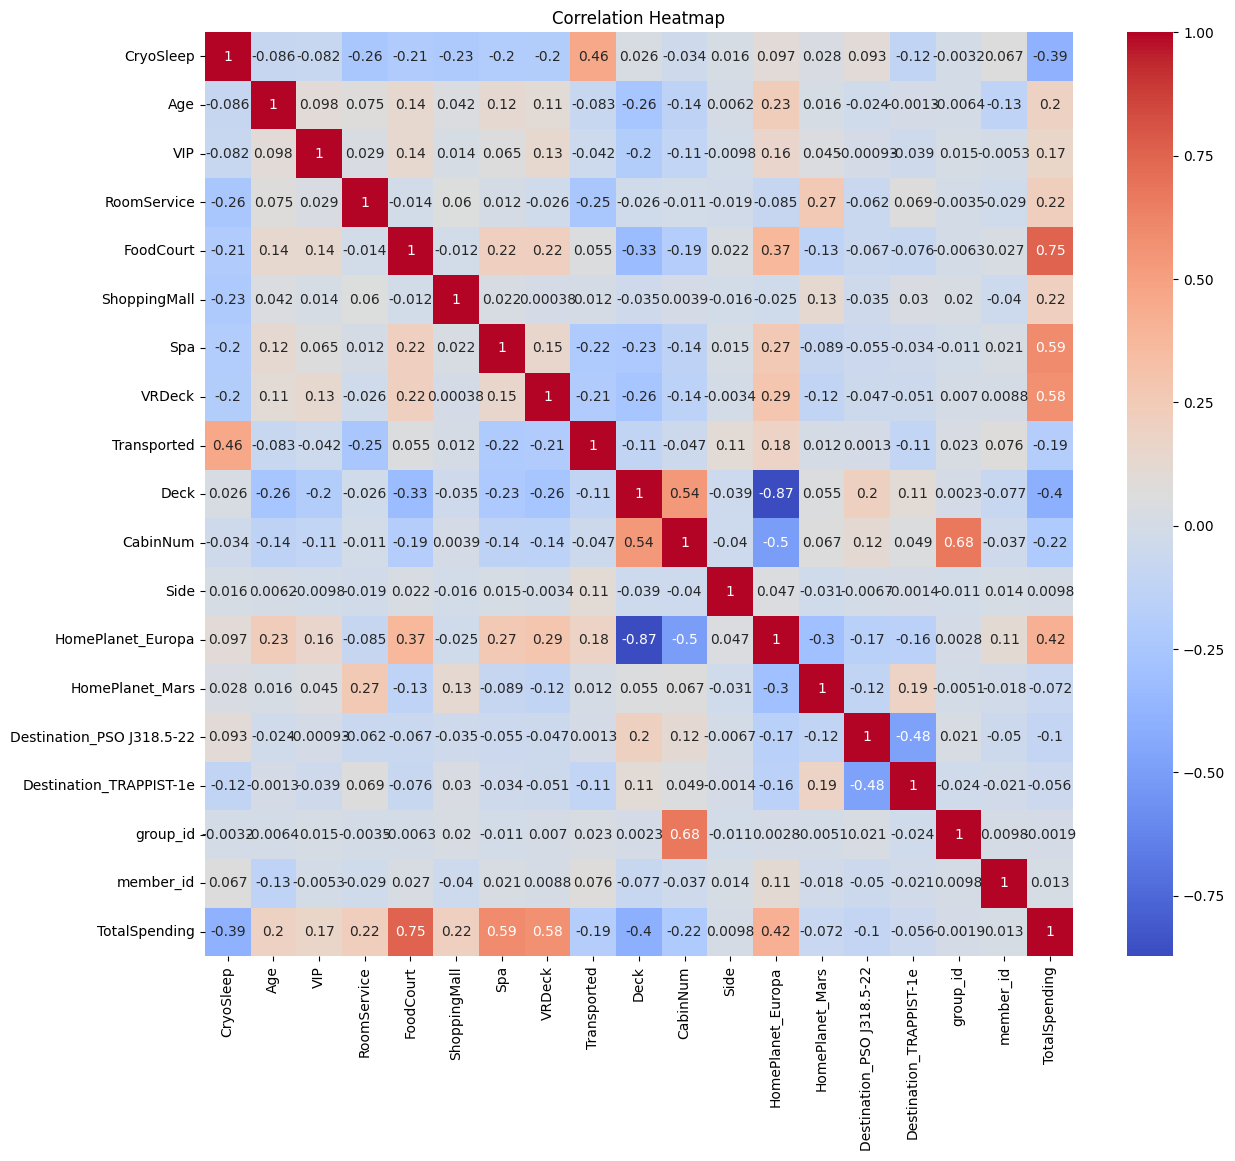

In [ ]:
corr = df.corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
df['Deck_Spend'] = df['VRDeck'] * df['HomePlanet_Europa']

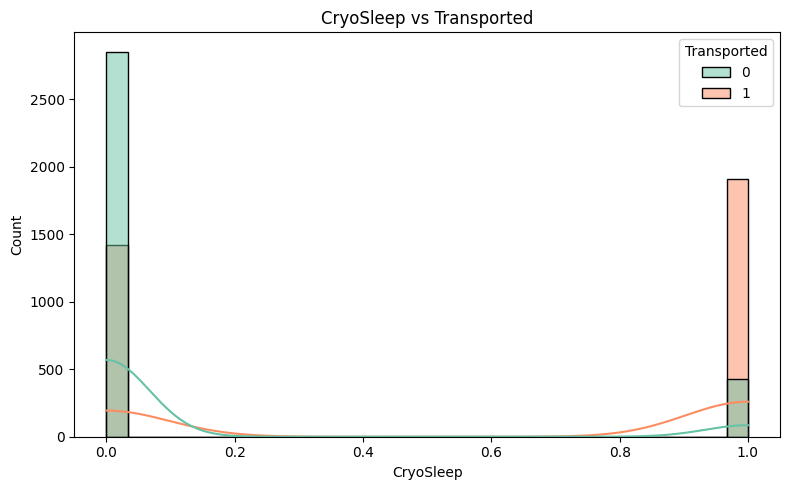

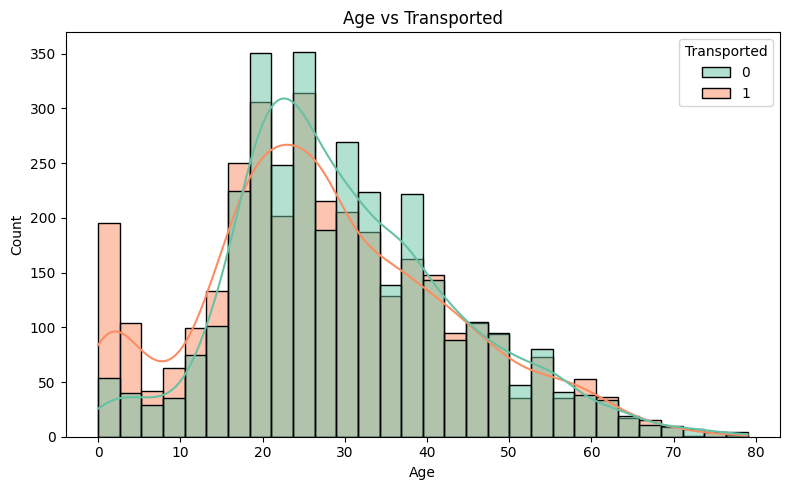

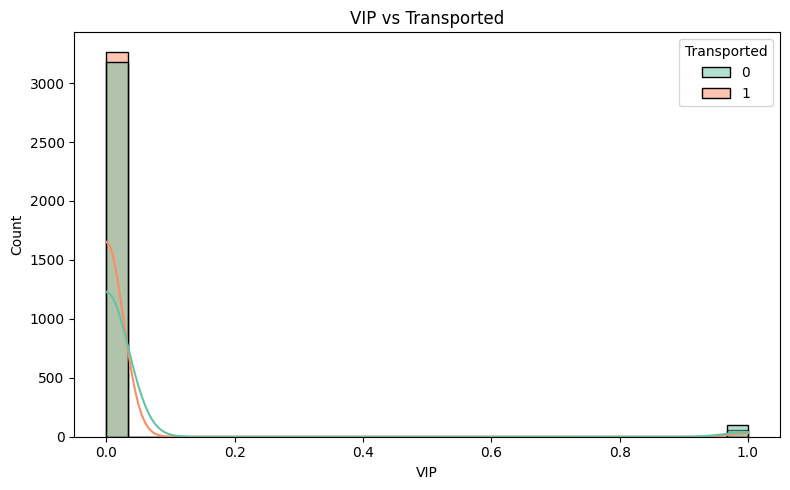

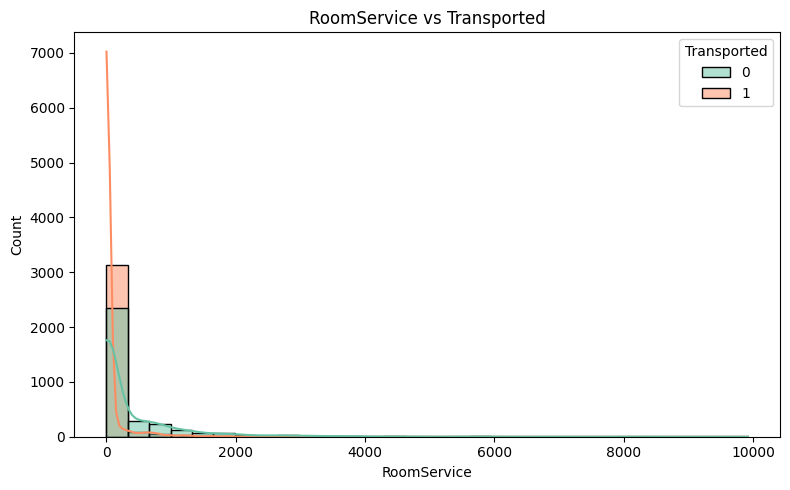

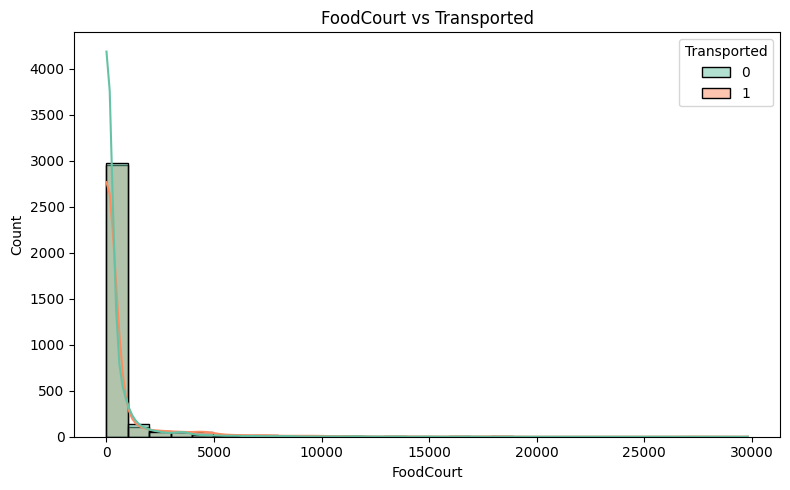

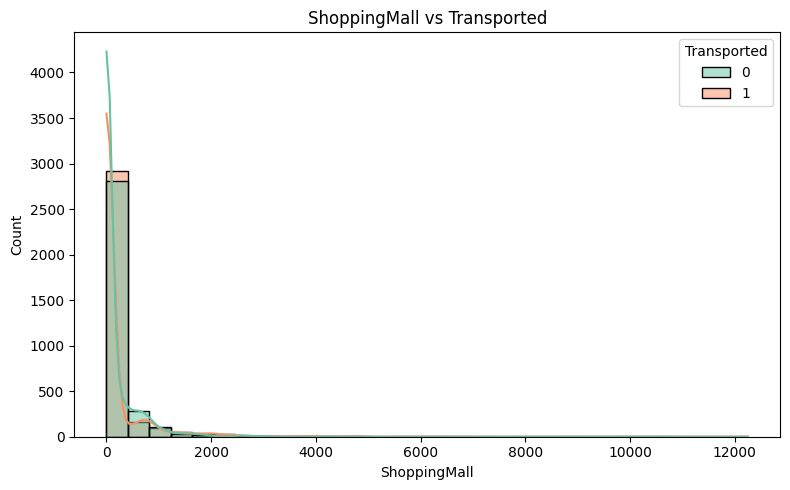

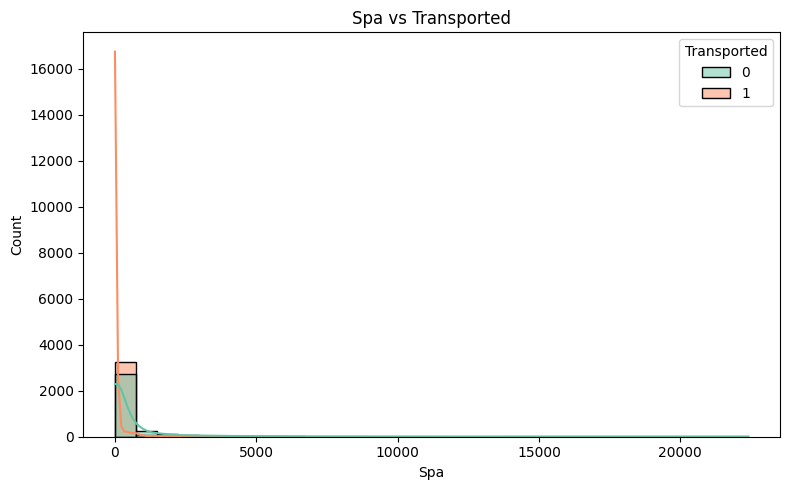

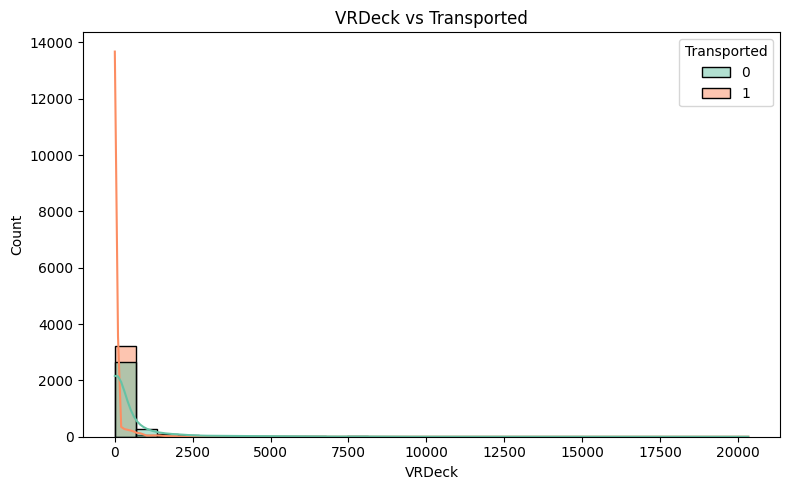

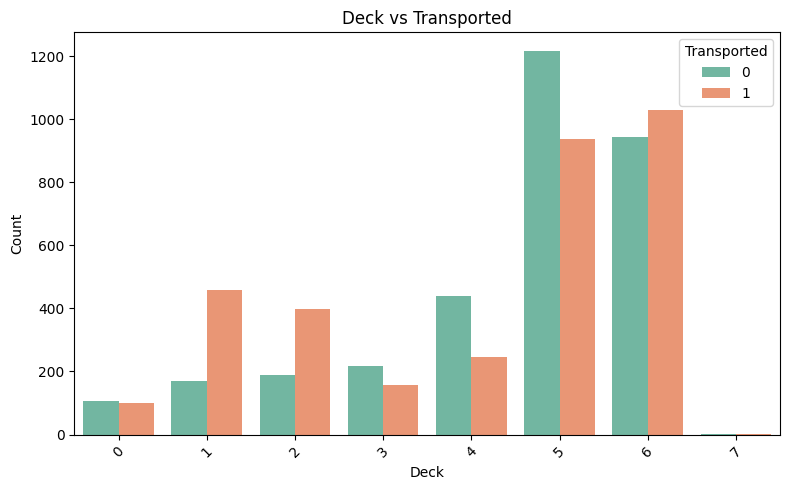

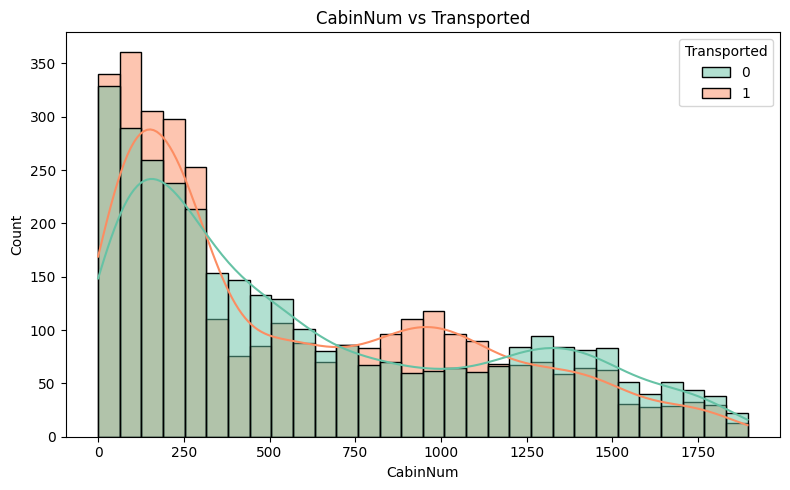

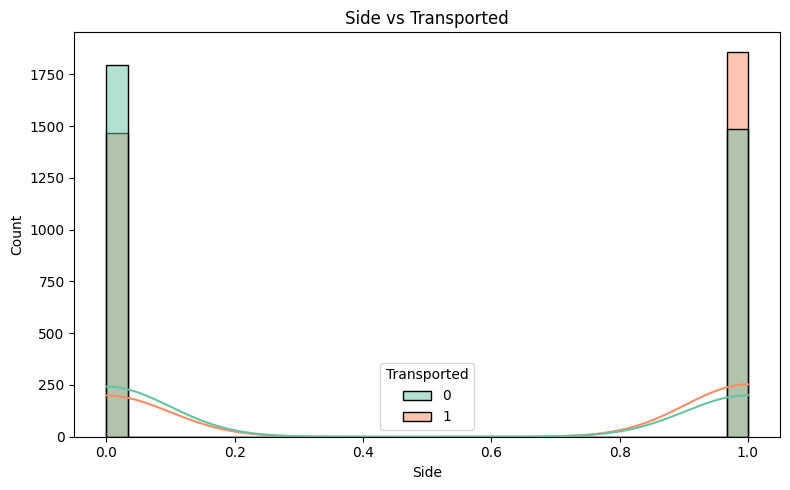

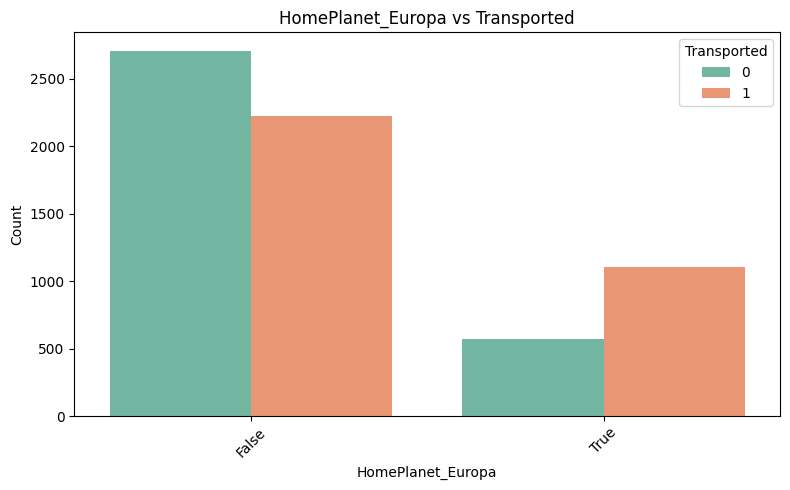

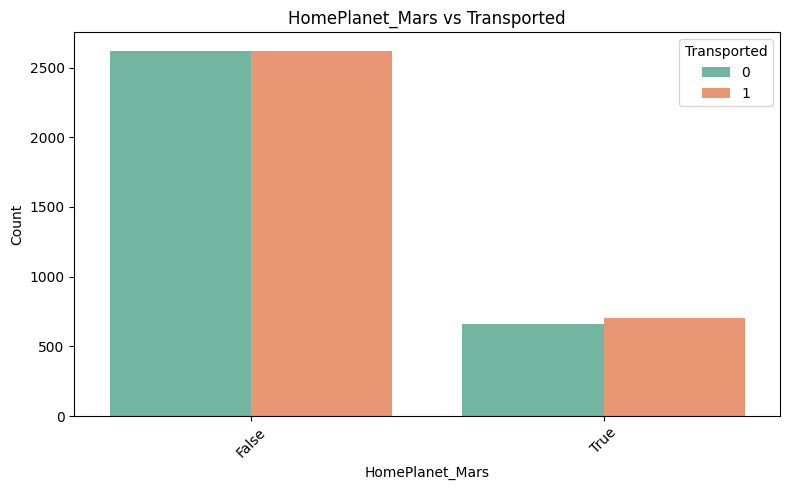

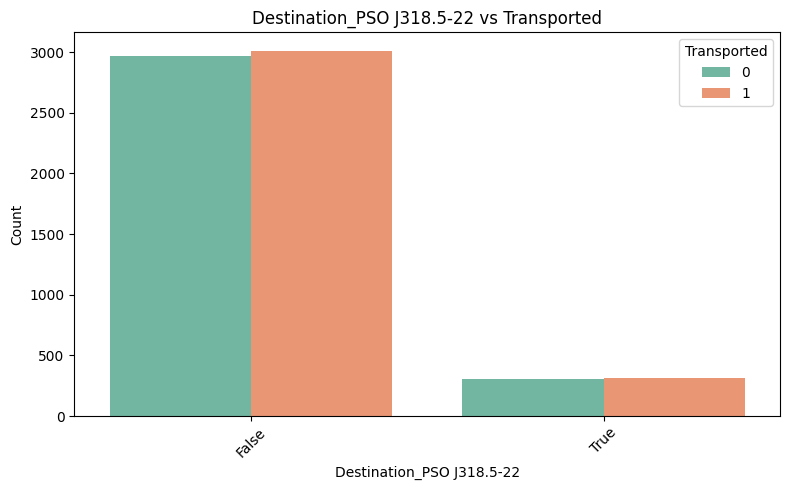

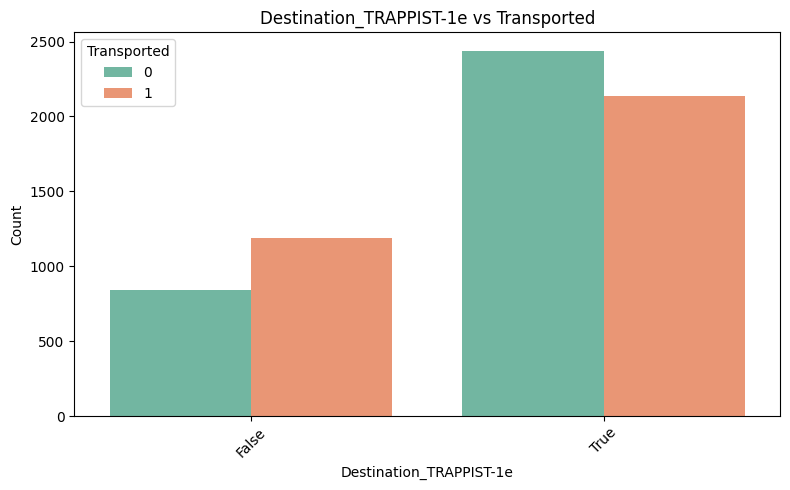

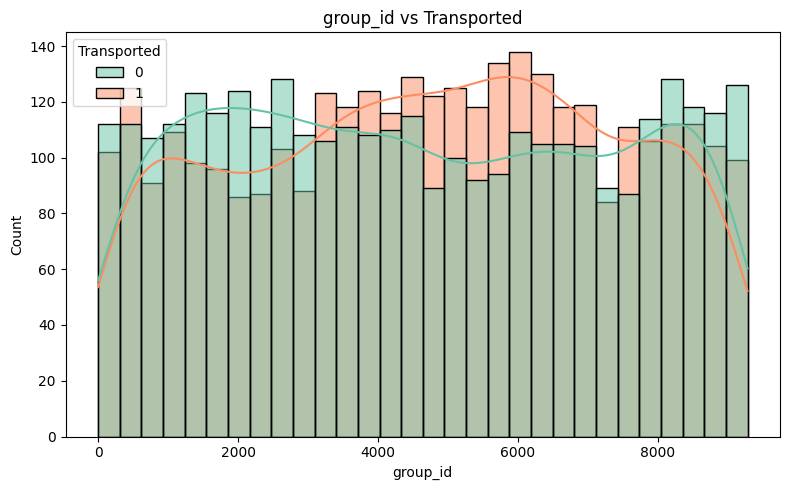

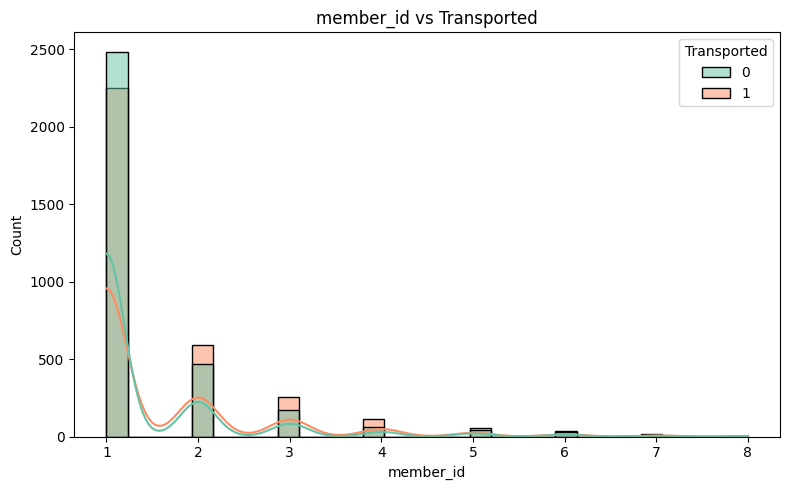

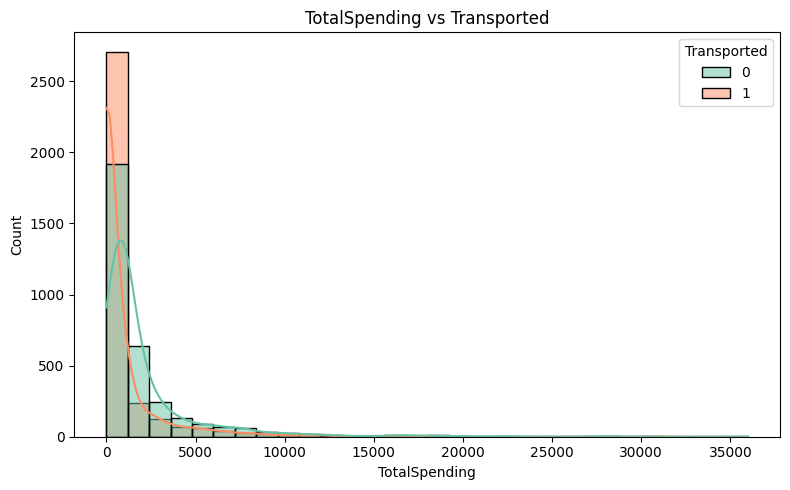

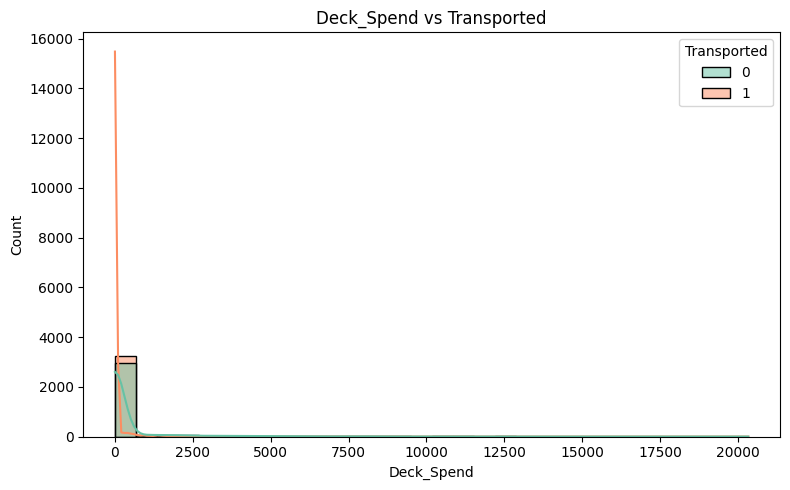

In [ ]:
target = "Transported"

for col in df.columns:
    if col == target:
        continue  # skip the target itself

    plt.figure(figsize=(8,5))

    if df[col].dtype in ['int64','float64']:
        # Numeric feature → distribution by Transported
        sns.histplot(data=df, x=col, hue=target, bins=30, kde=True, palette="Set2")
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel("Count")

    else:
        # Categorical feature → countplot by Transported
        sns.countplot(data=df, x=col, hue=target, palette="Set2")
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [ ]:
df.corr()['HomePlanet_Europa'].sort_values(ascending=False)


,HomePlanet_Europa
HomePlanet_Europa,1.000000
TotalSpending,0.416565
FoodCourt,0.374625
Deck_Spend,0.340417
VRDeck,0.290047
Spa,0.266354
Age,0.227537
Transported,0.182004
VIP,0.155231
member_id,0.109738


In [ ]:
from sklearn.model_selection import train_test_split
x= df.drop(['Transported','TotalSpending','Deck_Spend','CabinNum','Deck'],axis=1)
# x= df.drop(['Transported','TotalSpending','Age','Age_scaled','HomePlanet_Europa'],axis=1)

y= df['Transported']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='l2', solver='liblinear')
model.fit(x_train, y_train)

print("Model training complete. Here are the first 5 predictions on the test set:")
predictions = model.predict(x_test)
print(predictions[:5])

Model training complete. Here are the first 5 predictions on the test set:
[1 1 1 1 0]


In [ ]:
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter
# model.fit(x_train, y_train)

# print("Model training complete. Here are the first 5 predictions on the test set:")
# predictions = model.predict(x_test)
# print(predictions[:5])

In [ ]:
y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7980332829046899


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model_scaled = LogisticRegression(penalty='l2', solver='liblinear')
model_scaled.fit(x_train_scaled, y_train)

print("Model training complete with scaled data. Here are the first 5 predictions:")
predictions_scaled = model_scaled.predict(x_test_scaled)
print(predictions_scaled[:5])

Model training complete with scaled data. Here are the first 5 predictions:
[1 1 1 1 0]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = model_scaled.predict(x_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7965204236006052


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')) # Added eval_metric to suppress warning
])

params = [
    {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.7, 1.0],
        'model__colsample_bytree': [0.7, 1.0]
    }
]

grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy', n_jobs=-1) # Added n_jobs for parallel processing
grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
0.8012884880020643


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:32:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Scale the entire feature dataset for cross-validation
scaler_cv = StandardScaler() # Use a new scaler instance for cross-validation if needed, or reuse previous
x_scaled = scaler_cv.fit_transform(x)

# Define the cross-validation strategy
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the model (using a base XGBoost model)
cv_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Perform cross-validation
cv_scores = cross_val_score(cv_model, x_scaled, y, cv=kf, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation scores: [0.79273828 0.80469341 0.80999243 0.77895534 0.78046934]
Mean cross-validation accuracy: 0.7934
Standard deviation of cross-validation accuracy: 0.0125


In [ ]:
# @title
test_df = pd.read_csv('test.csv')
submission_passenger_ids = test_df['PassengerId']

# --- Imputation values from the preprocessed training DataFrame (df) ---
# For numerical features, use median
median_age = df['Age'].median()
median_roomservice = df['RoomService'].median()
median_foodcourt = df['FoodCourt'].median()
median_shoppingmall = df['ShoppingMall'].median()
median_spa = df['Spa'].median()
median_vrdeck = df['VRDeck'].median()
median_cabinnum = df['CabinNum'].median()

# For categorical features, use mode
mode_homeplanet = df['HomePlanet_Europa'].mode()[0] # HomePlanet was one-hot encoded in 'df'
mode_cryosleep = df['CryoSleep'].mode()[0]
mode_destination = df['Destination_TRAPPIST-1e'].mode()[0] # Destination was one-hot encoded in 'df'
mode_vip = df['VIP'].mode()[0]
mode_deck = df['Deck'].mode()[0]
mode_side = df['Side'].mode()[0]

# --- Create and fit LabelEncoders for CryoSleep and VIP from the training df ---
le_cryosleep = LabelEncoder()
le_vip = LabelEncoder()
le_cryosleep.fit(df['CryoSleep'])
le_vip.fit(df['VIP'])

def preprocess_test_data(df_input):
    temp_df = df_input.copy()

    # Drop Name
    temp_df.drop('Name', axis=1, inplace=True, errors='ignore')

    # Impute numerical features
    temp_df['Age'] = temp_df['Age'].fillna(median_age)
    temp_df['RoomService'] = temp_df['RoomService'].fillna(median_roomservice)
    temp_df['FoodCourt'] = temp_df['FoodCourt'].fillna(median_foodcourt)
    temp_df['ShoppingMall'] = temp_df['ShoppingMall'].fillna(median_shoppingmall)
    temp_df['Spa'] = temp_df['Spa'].fillna(median_spa)
    temp_df['VRDeck'] = temp_df['VRDeck'].fillna(median_vrdeck)

    # Impute categorical features before encoding for consistency
    # For HomePlanet and Destination, get_dummies will handle NaNs if not filled, but for consistency let's fill
    temp_df['HomePlanet'] = temp_df['HomePlanet'].fillna(mode_homeplanet)
    temp_df['Destination'] = temp_df['Destination'].fillna(mode_destination)
    temp_df['CryoSleep'] = temp_df['CryoSleep'].fillna(mode_cryosleep)
    temp_df['VIP'] = temp_df['VIP'].fillna(mode_vip)

    # Process Cabin
    temp_df['Cabin'] = temp_df['Cabin'].fillna('Z/9999/P') # Impute placeholder for splitting
    temp_df[['Deck', 'CabinNum', 'Side']] = temp_df['Cabin'].str.split('/', expand=True)
    temp_df['CabinNum'] = pd.to_numeric(temp_df['CabinNum'], errors='coerce')
    temp_df['CabinNum'] = temp_df['CabinNum'].fillna(median_cabinnum)
    temp_df['CabinNum'] = temp_df['CabinNum'].astype(int)
    temp_df['Deck'] = temp_df['Deck'].astype('category').cat.codes
    temp_df['Side'] = temp_df['Side'].map({'P':0, 'S':1})
    temp_df['Side'] = temp_df['Side'].fillna(mode_side) # Impute any NaNs in Side after map

    # Encode CryoSleep and VIP using the encoders fitted on training data
    temp_df['CryoSleep'] = le_cryosleep.transform(temp_df['CryoSleep'])
    temp_df['VIP'] = le_vip.transform(temp_df['VIP'])

    # One-hot encode HomePlanet and Destination
    temp_df = pd.get_dummies(temp_df, columns=['HomePlanet'], drop_first=True)
    temp_df = pd.get_dummies(temp_df, columns=['Destination'], drop_first=True)

    # Create 'group_id' and 'member_id'
    temp_df[['group_id', 'member_id']] = temp_df['PassengerId'].str.strip().str.split('_', expand=True)
    temp_df['group_id'] = pd.to_numeric(temp_df['group_id'], errors='coerce')
    temp_df['member_id'] = pd.to_numeric(temp_df['member_id'], errors='coerce')
    # Impute potential NaNs in group_id and member_id (e.g., if PassengerId format is bad)
    temp_df['group_id'] = temp_df['group_id'].fillna(temp_df['group_id'].median())
    temp_df['member_id'] = temp_df['member_id'].fillna(temp_df['member_id'].median())
    temp_df['group_id'] = temp_df['group_id'].astype(int)
    temp_df['member_id'] = temp_df['member_id'].astype(int)


    # Create Age_bin and one-hot encode
    temp_df['Age_bin'] = pd.cut(temp_df['Age'], bins=[0,12,18,30,50,80], labels=['Child','Teen','YoungAdult','Adult','Senior'])
    temp_df = pd.get_dummies(temp_df, columns=['Age_bin'], drop_first=True)

    # Create TotalSpending
    temp_df['TotalSpending'] = temp_df[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)

    # Create Deck_Spend
    if 'HomePlanet_Europa' not in temp_df.columns:
        temp_df['HomePlanet_Europa'] = False # If no Europa in test, set to False
    temp_df['Deck_Spend'] = temp_df['VRDeck'] * temp_df['HomePlanet_Europa']

    # Drop original 'Cabin' and 'PassengerId'
    temp_df.drop(['Cabin', 'PassengerId'], axis=1, inplace=True, errors='ignore')

    return temp_df

# Preprocess the test data
test_df_processed = preprocess_test_data(test_df)

# Align test_df_processed columns with x_train columns
# x is the training feature DataFrame from the kernel state
final_x_cols = x.columns.tolist()

# Add missing columns (if any) with 0
missing_cols = set(final_x_cols) - set(test_df_processed.columns)
for col in missing_cols:
    test_df_processed[col] = 0

# Drop extra columns (if any)
extra_cols = set(test_df_processed.columns) - set(final_x_cols)
test_df_processed.drop(columns=list(extra_cols), inplace=True)

# Reorder columns to match the training data
test_df_final = test_df_processed[final_x_cols]

# Make predictions using the best estimator from GridSearchCV
# The grid.best_estimator_ is a pipeline, so it handles scaling internally.
predictions = grid.best_estimator_.predict(test_df_final)

# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': submission_passenger_ids,
    'Transported': predictions.astype(bool) # Convert to boolean as per original 'Transported' type
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")
print(submission.head())

Submission file 'submission.csv' created successfully.
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False
